## In-class Classification

In [72]:
import pandas as pd

df = pd.read_csv('/Users/markkeith/Library/CloudStorage/GoogleDrive-mark.keith@gmail.com/My Drive/2-Teaching/Book 10-3 Predictive AI ML (BYU IS 355, 455)/Datasets/lc_small.csv')
df.head()

,loan_status,loan_status_numeric,loan_amnt,issue_d,term,int_rate,installment,total_pymnt,total_rec_prncp,total_rec_int,...,pub_rec,revol_bal,revol_util,tot_coll_amt,tot_cur_bal,total_acc,total_rev_hi_lim,dti,grade,sub_grade
0,Fully Paid,6,5500,2017-11-01,36 months,7.35,170.71,5869.266021,5500.00,369.27,...,0.0,7492,22.6,0.0,7492.0,9.0,33200.0,2.31,A,A4
1,Current,5,20000,2017-02-01,60 months,14.99,475.70,11375.160000,6275.78,5099.38,...,0.0,21482,64.5,0.0,29091.0,19.0,33300.0,16.03,C,C4
2,Current,5,25000,2018-11-01,36 months,7.02,772.16,2306.730000,1888.74,417.99,...,0.0,36104,39.3,0.0,567211.0,32.0,91900.0,17.63,A,A2
3,Current,5,16800,2018-07-01,36 months,15.02,582.55,4000.750000,2704.99,1295.76,...,0.0,29854,100.2,0.0,780426.0,8.0,29800.0,19.51,C,C3
4,Current,5,31300,2018-09-01,60 months,27.27,960.82,4709.260000,1305.65,3403.61,...,0.0,11301,45.9,0.0,494372.0,50.0,24600.0,50.55,E,E5


In [73]:
df.loan_status.value_counts()

loan_status
Current               6612
Fully Paid            2722
Charged Off            898
Late (31-120 days)     152
In Grace Period         56
Late (16-30 days)       36
Name: count, dtype: int64

In [74]:
import pandas as pd
from sklearn.model_selection import train_test_split

bad_statuses = {"Charged Off", "Default", "Late (31-120 days)"}
df["loan_good"] = (~df["loan_status"].isin(bad_statuses)).astype(int)
y = df["loan_good"].copy()
X = df.drop(columns=["loan_status", "loan_status_numeric", "loan_good"]).copy()

X_train_full, X_test, y_train_full, y_test = train_test_split(
  X, y, test_size=0.20, random_state=2, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
  X_train_full, y_train_full, test_size=0.25, random_state=2, stratify=y_train_full
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)
print("Positive class rate (loan_good=1):")
print("Train:", y_train.mean(), " Val:", y_val.mean(), " Test:", y_test.mean())

Train: (6285, 33)  Val: (2095, 33)  Test: (2096, 33)
Positive class rate (loan_good=1):
Train: 0.8997613365155132  Val: 0.8997613365155132  Test: 0.8998091603053435


In [75]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

numeric_pipe = Pipeline(steps=[
  ("imputer", SimpleImputer(strategy="median")),
  ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
  ("imputer", SimpleImputer(strategy="most_frequent")),
  ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
  transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
  ]
)

logit_model = Pipeline(steps=[
  ("prep", preprocessor),
  ("clf", LogisticRegression(max_iter=1000, random_state=2))
])

logit_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [76]:
y_val_pred = logit_model.predict(X_val)
y_val_proba = logit_model.predict_proba(X_val)

print("First 5 predicted classes:", y_val_pred[:50])
print("First 5 predicted probabilities (P(class=1)):", y_val_proba[:50, 1])

First 5 predicted classes: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]
First 5 predicted probabilities (P(class=1)): [0.99708473 0.89537929 0.9996763  0.93704969 0.962054   0.99974602
 0.98486989 0.98394134 0.99481733 0.87571493 0.9458273  0.68715281
 0.99342449 0.99337561 0.57961188 0.7743845  0.99978807 0.95050186
 0.93942941 0.9888562  0.9768565  0.90494465 0.97541999 0.99160678
 0.85291434 0.99868917 0.99604965 0.69413997 0.96666474 0.99395425
 0.9999872  0.88621834 0.73775543 0.94092609 0.14653014 0.97649809
 0.94831201 0.99324012 0.99341875 0.99927242 0.99457905 0.99596685
 0.98094989 0.8286126  0.99999965 0.83521412 0.99997199 0.99857561
 0.93044221 0.98662996]


In [77]:
# Print the coefficients
print("Coefficients:", logit_model.named_steps["clf"].coef_)

# Print the intercept
print("Intercept:", logit_model.named_steps["clf"].intercept_)



Coefficients: [[ 0.15237184  0.13274567 -1.95926238 ...  0.01696207 -0.14280054
   0.02378301]]
Intercept: [3.20794667]


In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, log_loss

tree_clf = DecisionTreeClassifier(
  max_depth=5,
  min_samples_leaf=20,
  criterion="gini",
  random_state=2
)

model = Pipeline(steps=[
  ("prep", preprocessor),
  ("tree", tree_clf)
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
acc = accuracy_score(y_test, y_pred)
ll = log_loss(y_test, y_prob)

print("Test accuracy:", round(acc, 4))
print("Test log loss:", round(ll, 4))

Test accuracy: 0.9065
Test log loss: 0.3168


In [79]:
from sklearn.metrics import accuracy_score, log_loss
import pandas as pd

results = []

for depth in [1, 2, 3, 4, 6, 8]:
  tree_clf = DecisionTreeClassifier(
    max_depth=depth,
    min_samples_leaf=1,
    criterion="gini",
    random_state=27
  )

  pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("tree", tree_clf)
  ])

  pipe.fit(X_train, y_train)
  y_train_pred = pipe.predict(X_train)
  y_train_prob = pipe.predict_proba(X_train)[:, 1]
  y_val_pred = pipe.predict(X_val)
  y_val_prob = pipe.predict_proba(X_val)[:, 1]

  results.append({
    "max_depth": depth,
    "train_accuracy": accuracy_score(y_train, y_train_pred),
    "val_accuracy": accuracy_score(y_val, y_val_pred),
    "train_log_loss": log_loss(y_train, y_train_prob),
    "val_log_loss": log_loss(y_val, y_val_prob)
  })

depth_results = pd.DataFrame(results)
depth_results

,max_depth,train_accuracy,val_accuracy,train_log_loss,val_log_loss
0,1,0.899761,0.899761,0.310940,0.315773
1,2,0.904057,0.897375,0.292749,0.301966
2,3,0.907717,0.900239,0.277308,0.325402
3,4,0.912172,0.903580,0.265182,0.415995
4,6,0.923150,0.909308,0.233558,0.488171
5,8,0.931742,0.905967,0.209821,0.765858


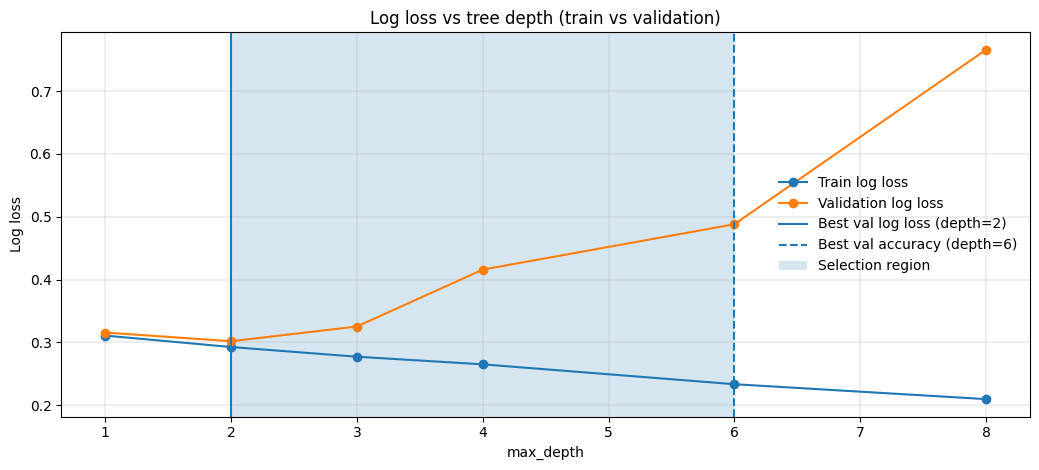

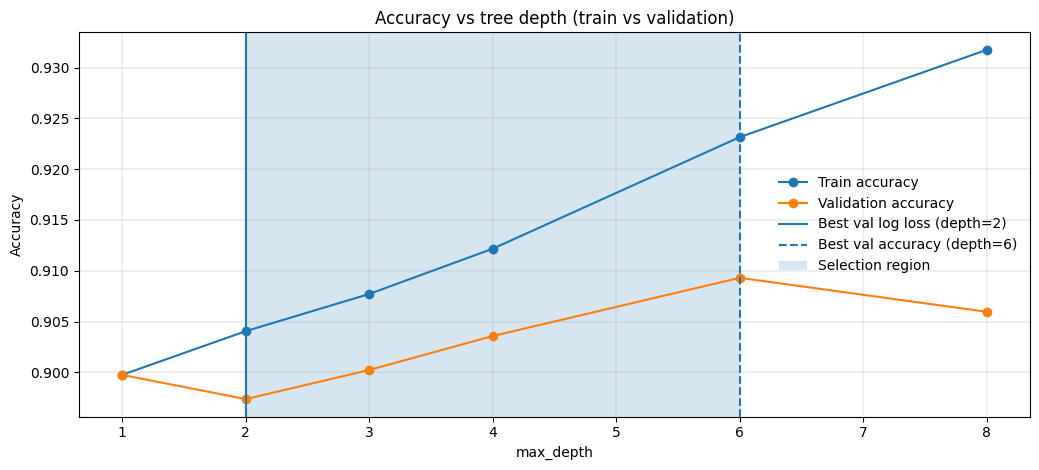

In [80]:
import matplotlib.pyplot as plt

best_ll_depth = int(depth_results.loc[depth_results["val_log_loss"].idxmin(), "max_depth"])
best_acc_depth = int(depth_results.loc[depth_results["val_accuracy"].idxmax(), "max_depth"])
left = min(best_ll_depth, best_acc_depth)
right = max(best_ll_depth, best_acc_depth)
x = depth_results["max_depth"].to_numpy()
plt.figure(figsize=(10.5, 4.8))
plt.plot(x, depth_results["train_log_loss"], marker="o", linewidth=1.5, label="Train log loss")
plt.plot(x, depth_results["val_log_loss"], marker="o", linewidth=1.5, label="Validation log loss")
plt.axvline(best_ll_depth, linewidth=1.5, label=f"Best val log loss (depth={best_ll_depth})")
plt.axvline(best_acc_depth, linewidth=1.5, linestyle="--", label=f"Best val accuracy (depth={best_acc_depth})")
plt.axvspan(left, right, alpha=0.18, label="Selection region")
plt.xlabel("max_depth")
plt.ylabel("Log loss")
plt.title("Log loss vs tree depth (train vs validation)")
plt.legend(frameon=False)
plt.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10.5, 4.8))
plt.plot(x, depth_results["train_accuracy"], marker="o", linewidth=1.5, label="Train accuracy")
plt.plot(x, depth_results["val_accuracy"], marker="o", linewidth=1.5, label="Validation accuracy")
plt.axvline(best_ll_depth, linewidth=1.5, label=f"Best val log loss (depth={best_ll_depth})")
plt.axvline(best_acc_depth, linewidth=1.5, linestyle="--", label=f"Best val accuracy (depth={best_acc_depth})")
plt.axvspan(left, right, alpha=0.18, label="Selection region")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs tree depth (train vs validation)")
plt.legend(frameon=False)
plt.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()

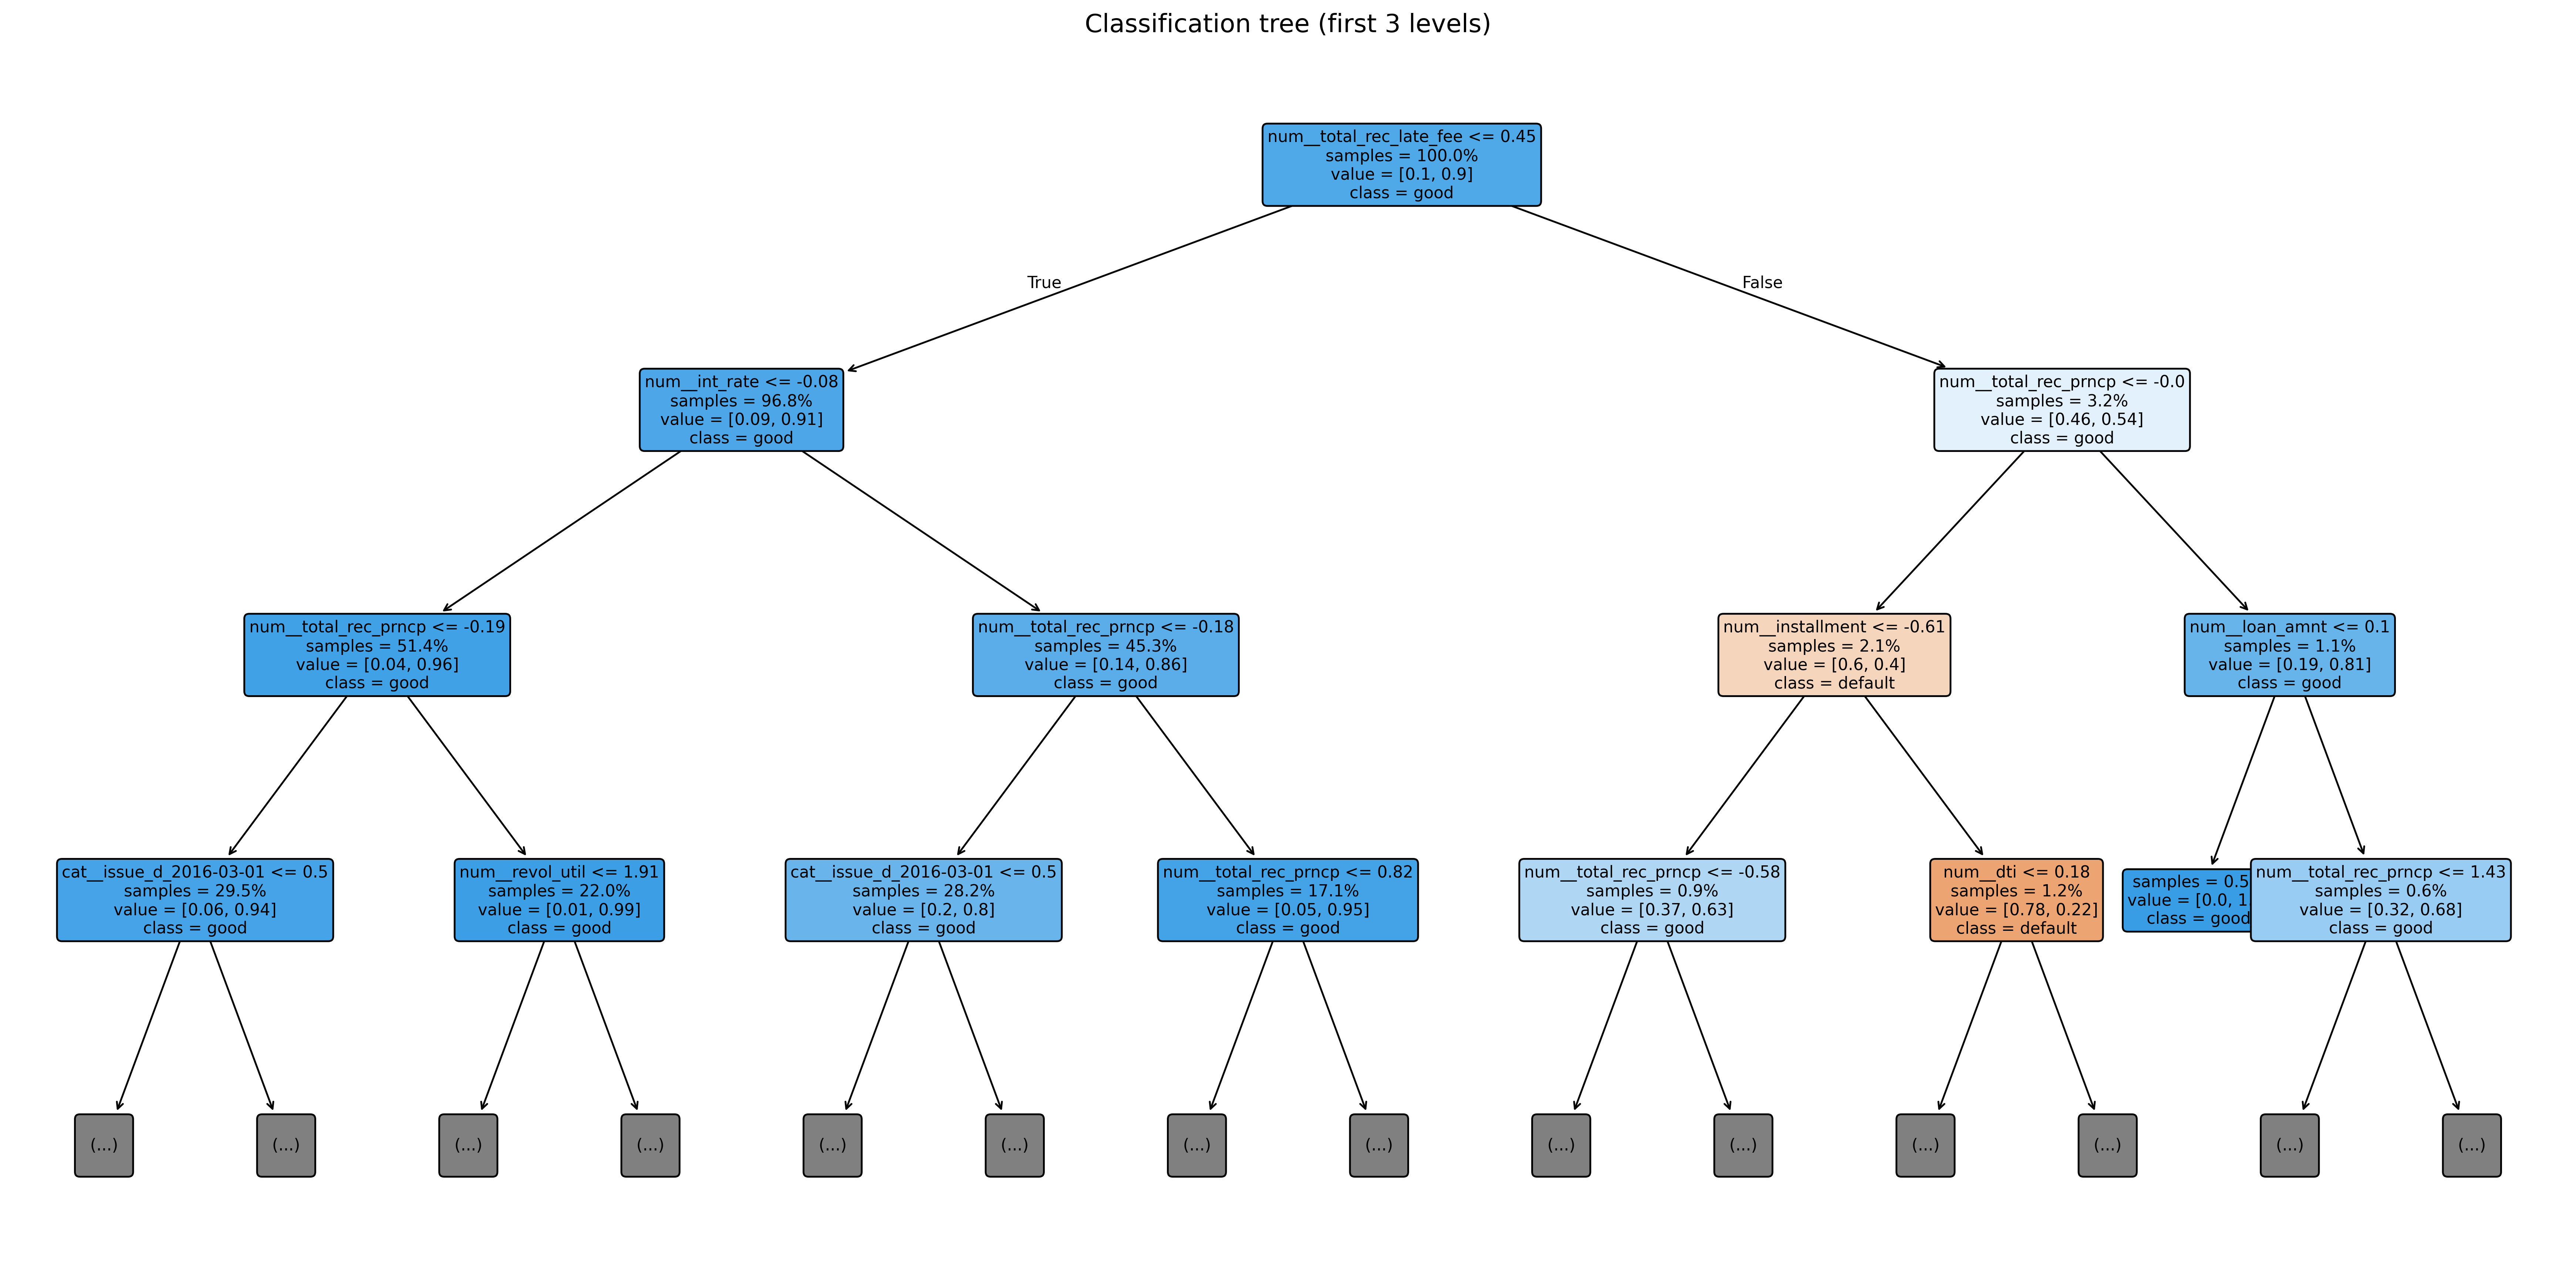

In [81]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

tree_model = model.named_steps["tree"]
plt.figure(figsize=(20, 10), dpi=350)

plot_tree(
  tree_model,
  feature_names=preprocessor.get_feature_names_out(),
  class_names=["default", "good"],
  filled=True,
  rounded=True,
  max_depth=3,
  fontsize=9,
  precision=2,
  proportion=True,
  impurity=False
)

plt.title("Classification tree (first 3 levels)", fontsize=14)
plt.tight_layout()
plt.show()

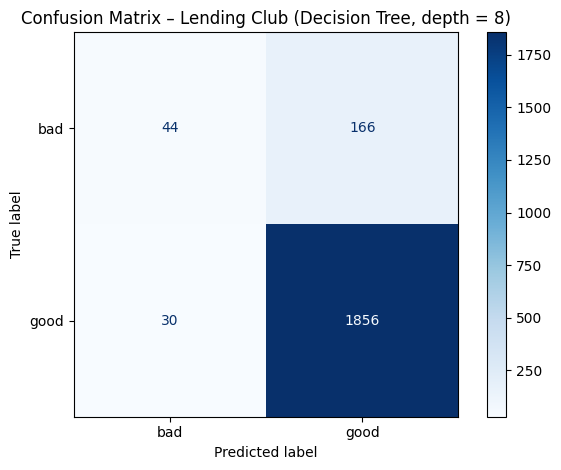

In [82]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Class predictions on test set
y_test_pred = model.predict(X_test)

# Confusion matrix (explicit label order)
cm = metrics.confusion_matrix(
  y_test,
  y_test_pred,
  labels=[0, 1] # Use numeric labels as they are in y_test
)

cm_display = metrics.ConfusionMatrixDisplay(cm, display_labels=["bad", "good"])
cm_display.plot(values_format="d", cmap="Blues")
plt.title("Confusion Matrix – Lending Club (Decision Tree, depth = 8)")
plt.tight_layout()
plt.show()